In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import os
import pickle

In [ ]:
def reconstruir_sim_data(folder_base, resolucion, destino_pkl, plantilla_params=None):
    frame_folder = os.path.join(folder_base, f"{resolucion}x{resolucion}_frames")
    if not os.path.isdir(frame_folder):
        raise FileNotFoundError(f"No se encontró la carpeta de frames: {frame_folder}")

    print(f"📂 Cargando frames desde: {frame_folder}")

    # Detectar todos los archivos u_*.npy
    archivos = sorted([f for f in os.listdir(frame_folder) if f.startswith("u_") and f.endswith(".npy")])
    n_frames = len(archivos)
    if n_frames == 0:
        raise ValueError("No se encontraron archivos u_*.npy")

    u_history = []
    v_history = []
    p_history = []
    T_history = []
    tau_history = []

    for archivo_u in archivos:
        n = int(archivo_u.split('_')[1].split('.')[0])
        archivo_v = f"v_{n:05d}.npy"
        archivo_p = f"p_{n:05d}.npy"
        
        u = np.load(os.path.join(frame_folder, archivo_u))
        v = np.load(os.path.join(frame_folder, archivo_v))
        p = np.load(os.path.join(frame_folder, archivo_p))
        
        # Inicializa campos constantes
        if len(u_history) == 0:
            ny, nx = u.shape
            x_star = np.linspace(0, 1.0, nx)
            y_star = np.linspace(0, 1.0, ny)
            X_star, Y_star = np.meshgrid(x_star, y_star)
            T = np.ones_like(u)
            tau = np.zeros_like(u)
        
        u_history.append(u)
        v_history.append(v)
        p_history.append(p)
        T_history.append(T.copy())
        tau_history.append(tau.copy())

    # Parámetros estimados o copiados
    if plantilla_params:
        with open(plantilla_params, 'rb') as f:
            base_params = pickle.load(f)["params"]
        dt_star = base_params["dt_star"]
        presion_adversa = base_params.get("presion_adversa", 0.3)
    else:
        dt_star = 1.0 / (n_frames - 1)
        presion_adversa = 0.2

    sim_data = {
        "u_history": u_history,
        "v_history": v_history,
        "p_history": p_history,
        "T_history": T_history,
        "tau_history": tau_history,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": n_frames,
            "presion_adversa": presion_adversa
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "frame_folder": frame_folder
    }

    # Guardar .pkl final
    os.makedirs(destino_pkl, exist_ok=True)
    archivo_pkl = os.path.join(destino_pkl, f"{resolucion}x{resolucion}.pkl")
    with open(archivo_pkl, 'wb') as f:
        pickle.dump(sim_data, f)

    print(f"✅ Archivo .pkl creado: {archivo_pkl}")


In [42]:
reconstruir_sim_data(
    folder_base='sim_separacion',
    resolucion=800,
    destino_pkl='sim_separacion',
)

reconstruir_sim_data(
    folder_base='sim_separacion',
    resolucion=1600,
    destino_pkl='sim_separacion',
)


📂 Cargando frames desde: sim_separacion/800x800_frames
✅ Archivo .pkl creado: sim_separacion/800x800.pkl
📂 Cargando frames desde: sim_separacion/1600x1600_frames
✅ Archivo .pkl creado: sim_separacion/1600x1600.pkl


In [ ]:
def animar_resultados(sim_data):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    resolucion = X_star.shape[1]
    presion_adversa = sim_data["params"].get("presion_adversa", "N/A")

    fig, axs_grid = plt.subplots(3, 2, figsize=(12, 12))
    axs = axs_grid.flatten()

    titles = [
        'Velocidad |u*|',
        'Temperatura T*',
        'Presión p*',
        'Esfuerzo cortante τ*',
        'Componente u*',
        'Componente v*'
    ]
    cmaps = ['jet', 'jet', 'viridis', 'coolwarm', 'plasma', 'plasma']

    # Primer frame
    datasets = [
        np.sqrt(u_hist[0]**2 + v_hist[0]**2),
        T_hist[0],
        p_hist[0],
        tau_hist[0],
        u_hist[0],
        v_hist[0]
    ]

    for ax, title, cmap, data in zip(axs, titles, cmaps, datasets):
        cf = ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel("x*")
        ax.set_ylabel("y*")
        plt.colorbar(cf, ax=ax)

    t_star_0 = 0.0
    fig.suptitle(f"Resolución {resolucion}x{resolucion} | presión_adversa = {presion_adversa} | t* = {t_star_0:.2f}", fontsize=14)
    plt.tight_layout()

    def update(frame):
        t_star = frame / (len(u_hist) - 1)
        updated_data = [
            np.sqrt(u_hist[frame]**2 + v_hist[frame]**2),
            T_hist[frame],
            p_hist[frame],
            tau_hist[frame],
            u_hist[frame],
            v_hist[frame]
        ]
        for ax, data, cmap in zip(axs, updated_data, cmaps):
            for coll in list(ax.collections):
                coll.remove()
            ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)

        fig.suptitle(f"Resolución {resolucion}x{resolucion} | presión_adversa = {presion_adversa} | t* = {t_star:.2f}", fontsize=14)

        return axs

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


In [43]:
from matplotlib.animation import FFMpegWriter


# Resoluciones que deseas procesar
resoluciones = [800, 1600]

# Carpeta donde se guardan los .pkl

carpeta = 'sim_separacion'

# Carpeta destino de las animaciones
carpeta_anim = "anim_sep_bubble"
os.makedirs(carpeta_anim, exist_ok=True)

for res in resoluciones:
    try:
        # Cargar datos
        nombre_pkl = os.path.join(carpeta, f"{res}x{res}.pkl")
        with open(nombre_pkl, "rb") as f:
            sim_data = pickle.load(f)

        # Generar animación
        anim, fig = animar_resultados(sim_data)

        # Guardar como .mp4
        salida = os.path.join(carpeta_anim, f"{res}x{res}.mp4")
        writer = FFMpegWriter(fps=30)
        anim.save(salida, writer=writer)
        plt.close(fig)

        print(f"✅ Animación guardada para resolución {res} en {salida}")

    except Exception as e:
        print(f"❌ Error al procesar resolución {res}: {e}")


✅ Animación guardada para resolución 800 en anim_sep_bubble/800x800.mp4
✅ Animación guardada para resolución 1600 en anim_sep_bubble/1600x1600.mp4


In [1]:
def calcular_parametros(sim_data):
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    final_u = u_hist[-1]

    # Tomamos la línea más baja (y≈0)
    y_line_idx = 1  # la segunda fila desde abajo
    u_bottom = final_u[y_line_idx, :]
    x_vals = X[y_line_idx, :]

    # Buscar cambio de signo de positivo a negativo (indica separación)
    signo = np.sign(u_bottom)
    cambios = np.where(np.diff(signo) < 0)[0]

    x_sep = None
    if len(cambios) > 0:
        x_sep = x_vals[cambios[0]]
    
    # Buscar burbuja de recirculación (donde u < 0)
    indices_negativos = np.where(u_bottom < 0)[0]
    bubble = None
    if len(indices_negativos) > 1:
        bubble = x_vals[indices_negativos[-1]] - x_vals[indices_negativos[0]]

    # Calcular delta como grosor de la capa límite al final
    y_vals = Y[:, -1]  # columna más a la derecha
    u_profile = final_u[:, -1]
    u_inf = np.max(u_profile)
    delta = None
    for i in range(len(u_profile)):
        if u_profile[i] >= 0.99 * u_inf:
            delta = y_vals[i]
            break

    return x_sep, bubble, delta


In [6]:
# Asegúrate de que calcular_parametros está definida antes de este bloque

# --- Configuración ---
carpeta = 'sim_separacion'
resoluciones = [25, 50, 100, 200, 400, 800, 1600]

# --- Resultados del análisis ---
resultados = []

def cargar_datos(resolucion):
    nombre_archivo = os.path.join(carpeta, f"{resolucion}x{resolucion}.pkl")
    with open(nombre_archivo, 'rb') as f:
        data = pickle.load(f)
    return data

# --- Carga y análisis de datos ---
for res in resoluciones:
    try:
        datos = cargar_datos(res)
        x_sep, bubble, delta = calcular_parametros(datos)
        resultados.append({
            'resolucion': res,
            'x_sep': x_sep,
            'bubble_size': bubble,
            'delta': delta
        })
    except Exception as e:
        print(f"❌ Error al procesar resolución {res}: {e}")

# --- Mostrar resultados individuales ---
for r in resultados:
    print(f"{r['resolucion']}x{r['resolucion']} -> "
          f"x_sep: {r['x_sep']}, bubble: {r['bubble_size']}, delta: {r['delta']}")

# --- Variables para análisis de convergencia ---
resoluciones_validas = [r['resolucion'] for r in resultados if r['delta'] is not None]
x_sep_vals = [r['x_sep'] for r in resultados if r['x_sep'] is not None]
bubble_vals = [r['bubble_size'] for r in resultados if r['bubble_size'] is not None]
delta_vals = [r['delta'] for r in resultados if r['delta'] is not None]


❌ Error al procesar resolución 1600: [Errno 2] No such file or directory: 'sim_separacion/1600x1600.pkl'
25x25 -> x_sep: 0.125, bubble: 0.8333333333333334, delta: 1.0
50x50 -> x_sep: 0.08163265306122448, bubble: 0.8979591836734694, delta: 1.0
100x100 -> x_sep: 0.04040404040404041, bubble: 0.9494949494949495, delta: 1.0
200x200 -> x_sep: 0.020100502512562814, bubble: 0.9748743718592965, delta: 1.0
400x400 -> x_sep: 0.010025062656641603, bubble: 0.987468671679198, delta: 1.0
800x800 -> x_sep: 0.0050062578222778474, bubble: 0.9937421777221527, delta: 0.9987484355444306


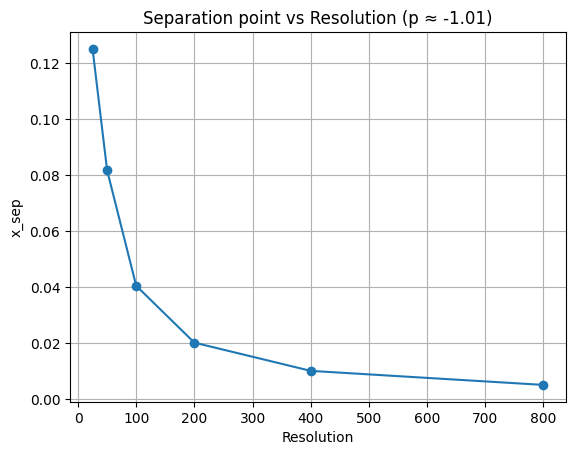

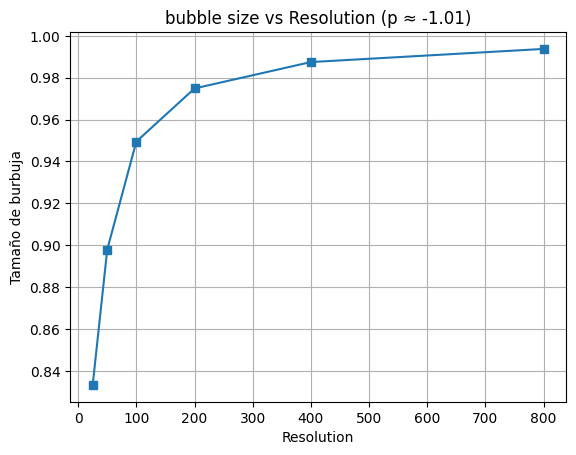

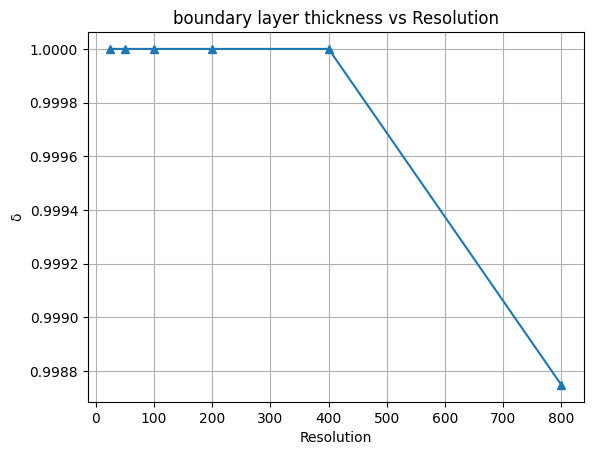

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Datos obtenidos
resoluciones = [25, 50, 100, 200, 400, 800]

# Función para calcular orden de convergencia
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

# Calcular orden de convergencia (solo con los 3 valores más refinados)
r = 2
p_xsep = orden_convergencia(x_sep_vals[2], x_sep_vals[3], x_sep_vals[4], r)
p_bubble = orden_convergencia(bubble_vals[2], bubble_vals[3], bubble_vals[4], r)

# delta es casi constante; su orden no es confiable
delta_casi_constante = all(np.isclose(d, 1.0) for d in delta_vals[:-1])
p_delta = None if delta_casi_constante else orden_convergencia(delta_vals[2], delta_vals[3], delta_vals[4], r)

# Gráfica para x_sep
plt.figure()
plt.plot(resoluciones, x_sep_vals, marker='o')
plt.title(f'Separation point vs Resolution (p ≈ {p_xsep:.2f})')
plt.xlabel('Resolution')
plt.ylabel('x_sep')
plt.grid()

# Gráfica para tamaño de burbuja
plt.figure()
plt.plot(resoluciones, bubble_vals, marker='s')
plt.title(f'bubble size vs Resolution (p ≈ {p_bubble:.2f})')
plt.xlabel('Resolution')
plt.ylabel('Tamaño de burbuja')
plt.grid()

# Gráfica para delta
plt.figure()
plt.plot(resoluciones, delta_vals, marker='^')
title = 'boundary layer thickness vs Resolution'
if p_delta is not None:
    title += f' (p ≈ {p_delta:.2f})'
plt.title(title)
plt.xlabel('Resolution')
plt.ylabel('δ')
plt.grid()

plt.show()


In [11]:
def generar_observaciones(sim_data, n_sensores=20):
    X = sim_data['X_star']
    T = sim_data['T_history'][-1]
    p = sim_data['p_history'][-1]
    tau = sim_data['tau_history'][-1]

    x_superficie = X[0, :]
    ny, nx = X.shape

    # Posiciones equidistantes de sensores
    posiciones_x = np.linspace(x_superficie[0], x_superficie[-1], n_sensores)
    indices_x = [np.argmin(np.abs(x_superficie - x)) for x in posiciones_x]

    T_obs = T[0, indices_x]
    p_obs = p[0, indices_x]
    tau_obs = tau[0, indices_x]

    observaciones = {
        'x': posiciones_x,
        'T': T_obs,
        'p': p_obs,
        'tau': tau_obs
    }
    return observaciones


In [12]:
resoluciones_bajas = [25, 50, 100, 200, 400]
observaciones_por_res = {}

for res in resoluciones_bajas:
    try:
        datos = cargar_datos(res)
        obs = generar_observaciones(datos, n_sensores=30)
        observaciones_por_res[res] = obs
    except Exception as e:
        print(f"⚠️ No se pudieron generar observaciones para {res}x{res}: {e}")
